In [1]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

True
Tesla T4


In [2]:
!pip install -q transformers torch torchvision pillow matplotlib numpy opencv-python

In [3]:
from transformers import pipeline
import torch

device = 0 if torch.cuda.is_available() else -1

depth_pipe = pipeline(
    "depth-estimation",
    model="depth-anything/Depth-Anything-V2-Small-hf",
    device=device
)

config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 99.2MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

In [4]:
from PIL import Image

image = Image.open("biking in nyc _3.jpg").convert("RGB")

result = depth_pipe(image)

depth = result["depth"]

print(type(depth))
print(depth.size)

<class 'PIL.Image.Image'>
(736, 981)


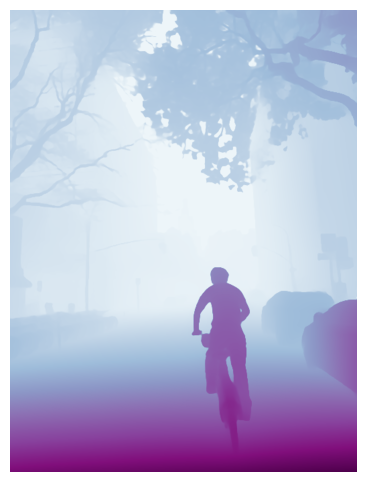

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.imshow(depth, cmap="BuPu")
plt.axis("off")
plt.show()

In [6]:
import numpy as np

depth_array = np.array(depth)

print("Shape:", depth_array.shape)
print("Data type:", depth_array.dtype)
print("Minimum:", depth_array.min())
print("Maximum:", depth_array.max())
print("Mean:", depth_array.mean())

Shape: (981, 736)
Data type: uint8
Minimum: 0
Maximum: 255
Mean: 86.92519971856579


In [7]:
print(result.keys())

dict_keys(['predicted_depth', 'depth'])


In [8]:
raw_depth = result["predicted_depth"]

print(type(raw_depth))
print(raw_depth.shape)
print(raw_depth.dtype)

<class 'torch.Tensor'>
torch.Size([981, 736])
torch.float32


In [9]:
depth_array = raw_depth.detach().cpu().numpy()

print("Shape:", depth_array.shape)
print("Data type:", depth_array.dtype)
print("Minimum:", depth_array.min())
print("Maximum:", depth_array.max())
print("Mean:", depth_array.mean())

Shape: (981, 736)
Data type: float32
Minimum: -0.43340418
Maximum: 7.4676275
Mean: 2.2760365


In [10]:
np.save("depth.npy", depth_array)

print("Saved depth.npy")

Saved depth.npy


In [11]:
import cv2

depth_min = depth_array.min()
depth_max = depth_array.max()

depth_normalized = (
    (depth_array - depth_min) /
    (depth_max - depth_min)
)

depth_16bit = (depth_normalized * 65535).astype(np.uint16)

cv2.imwrite("depth_16bit.png", depth_16bit)

print("Saved depth_16bit.png")

Saved depth_16bit.png


In [12]:
import numpy as np

saved_depth = np.load("depth.npy")

print("Shape:", saved_depth.shape)
print("Data type:", saved_depth.dtype)
print("Minimum:", saved_depth.min())
print("Maximum:", saved_depth.max())

Shape: (981, 736)
Data type: float32
Minimum: -0.43340418
Maximum: 7.4676275


In [13]:
import os
import cv2
import numpy as np
from PIL import Image

def estimate_depth(image_path, output_dir="depth_output"):

    os.makedirs(output_dir, exist_ok=True)

    image = Image.open(image_path).convert("RGB")

    result = depth_pipe(image)

    raw_depth = result["predicted_depth"]

    depth_array = raw_depth.detach().cpu().numpy().astype(np.float32)

    np.save(
        os.path.join(output_dir, "depth.npy"),
        depth_array
    )

    depth_min = depth_array.min()
    depth_max = depth_array.max()

    normalized = (
        (depth_array - depth_min) /
        (depth_max - depth_min + 1e-8)
    )

    depth_16bit = (
        normalized * 65535
    ).astype(np.uint16)

    cv2.imwrite(
        os.path.join(output_dir, "depth_16bit.png"),
        depth_16bit
    )

    visualization = (
        normalized * 255
    ).astype(np.uint8)

    visualization = cv2.applyColorMap(
        visualization,
        cv2.COLORMAP_INFERNO
    )

    cv2.imwrite(
        os.path.join(output_dir, "depth_visual.png"),
        visualization
    )

    print("Depth estimation completed.")
    print("Shape:", depth_array.shape)
    print("Data type:", depth_array.dtype)
    print("Minimum:", depth_min)
    print("Maximum:", depth_max)

    return depth_array

In [17]:
depth = estimate_depth("biking in nyc _3.jpg")

Depth estimation completed.
Shape: (981, 736)
Data type: float32
Minimum: -0.43340418
Maximum: 7.4676275


In [14]:
depth2 = estimate_depth("Nyc Aesthetic.jpg")

Depth estimation completed.
Shape: (1308, 736)
Data type: float32
Minimum: -0.8511909
Maximum: 8.545598


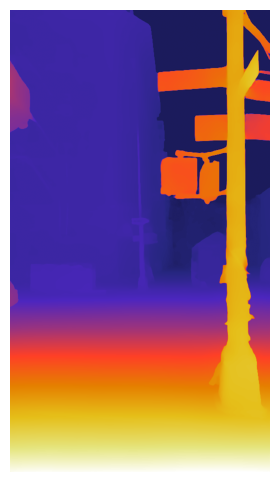

In [15]:
plt.figure(figsize=(10, 6))
plt.imshow(depth2, cmap="CMRmap")
plt.axis("off")
plt.show()

In [16]:
aerial_depth = estimate_depth("Drone Wallpaper.jpg")

Depth estimation completed.
Shape: (1308, 736)
Data type: float32
Minimum: 0.75050193
Maximum: 4.0493836


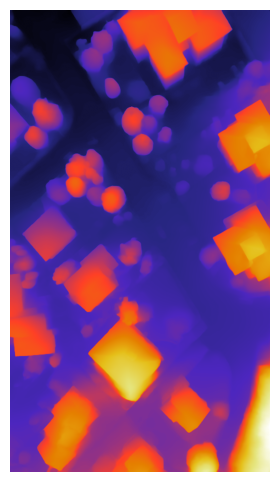

In [17]:
plt.figure(figsize=(10, 6))
plt.imshow(aerial_depth, cmap="CMRmap")
plt.axis("off")
plt.show()

In [18]:
print("Shape:", aerial_depth.shape)
print("Data type:", aerial_depth.dtype)
print("Minimum:", aerial_depth.min())
print("Maximum:", aerial_depth.max())
print("Mean:", aerial_depth.mean())

Shape: (1308, 736)
Data type: float32
Minimum: 0.75050193
Maximum: 4.0493836
Mean: 1.7531949


In [19]:
np.save("aerial_depth.npy", aerial_depth)

print("Saved aerial_depth.npy")

Saved aerial_depth.npy


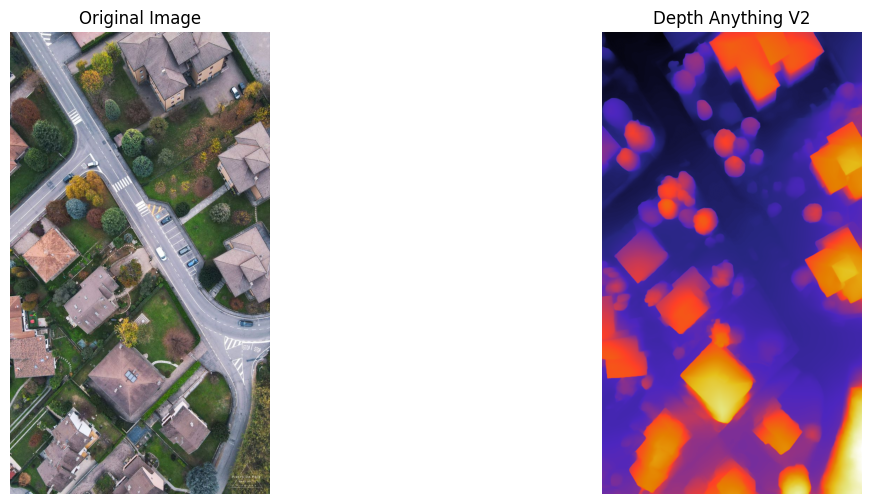

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

original = Image.open("Drone Wallpaper.jpg").convert("RGB")

axes[0].imshow(original)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(aerial_depth, cmap="CMRmap")
axes[1].set_title("Depth Anything V2")
axes[1].axis("off")

plt.show()

In [21]:
import os
import json
import cv2
import numpy as np
from PIL import Image

def estimate_depth(image_path, output_dir="depth_output"):

    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image not found: {image_path}")

    os.makedirs(output_dir, exist_ok=True)

    image = Image.open(image_path).convert("RGB")

    original_width, original_height = image.size

    if original_width < 64 or original_height < 64:
        raise ValueError("Image is too small. Minimum size is 64x64 pixels.")

    result = depth_pipe(image)

    raw_depth = result["predicted_depth"]

    depth_array = (
        raw_depth
        .detach()
        .cpu()
        .numpy()
        .astype(np.float32)
    )

    depth_height, depth_width = depth_array.shape

    if (depth_width, depth_height) != (
        original_width,
        original_height
    ):
        depth_array = cv2.resize(
            depth_array,
            (original_width, original_height),
            interpolation=cv2.INTER_LINEAR
        )

    np.save(
        os.path.join(output_dir, "depth.npy"),
        depth_array
    )

    depth_min = float(depth_array.min())
    depth_max = float(depth_array.max())

    normalized = (
        (depth_array - depth_min) /
        (depth_max - depth_min + 1e-8)
    )

    depth_16bit = (
        normalized * 65535
    ).astype(np.uint16)

    cv2.imwrite(
        os.path.join(output_dir, "depth_16bit.png"),
        depth_16bit
    )

    visualization = (
        normalized * 255
    ).astype(np.uint8)

    visualization = cv2.applyColorMap(
        visualization,
        cv2.COLORMAP_INFERNO
    )

    cv2.imwrite(
        os.path.join(output_dir, "depth_visual.png"),
        visualization
    )

    metadata = {
        "model": "Depth Anything V2 Small",
        "input_image": os.path.basename(image_path),
        "image_width": original_width,
        "image_height": original_height,
        "depth_width": int(depth_array.shape[1]),
        "depth_height": int(depth_array.shape[0]),
        "data_type": "float32",
        "representation": "relative_depth",
        "min_value": depth_min,
        "max_value": depth_max
    }

    with open(
        os.path.join(output_dir, "metadata.json"),
        "w"
    ) as f:
        json.dump(metadata, f, indent=4)

    print("Depth estimation completed.")
    print("Image size:", (original_width, original_height))
    print("Depth size:", depth_array.shape)
    print("Data type:", depth_array.dtype)
    print("Minimum:", depth_min)
    print("Maximum:", depth_max)

    return depth_array

In [22]:
import os
import shutil

if os.path.exists("depth_output"):
    shutil.rmtree("depth_output")

print("Old depth output removed.")

Old depth output removed.


In [23]:
depth = estimate_depth("biking in nyc _3.jpg")

Depth estimation completed.
Image size: (736, 981)
Depth size: (981, 736)
Data type: float32
Minimum: -0.43340417742729187
Maximum: 7.46762752532959


In [24]:
from PIL import Image
import numpy as np

image = Image.open("biking in nyc _3.jpg")
saved_depth = np.load("depth_output/depth.npy")

print("Image:", image.size)
print("Depth:", saved_depth.shape)

assert image.size == (
    saved_depth.shape[1],
    saved_depth.shape[0]
)

print("Alignment check: PASSED")

Image: (736, 981)
Depth: (981, 736)
Alignment check: PASSED


In [25]:
from PIL import Image
import numpy as np

image = Image.open("biking in nyc _3.jpg")

saved_depth = np.load("depth_output/depth.npy")

print("Image:", image.size)
print("Depth:", saved_depth.shape)

assert image.size == (
    saved_depth.shape[1],
    saved_depth.shape[0]
)

print("Alignment check: PASSED")

Image: (736, 981)
Depth: (981, 736)
Alignment check: PASSED


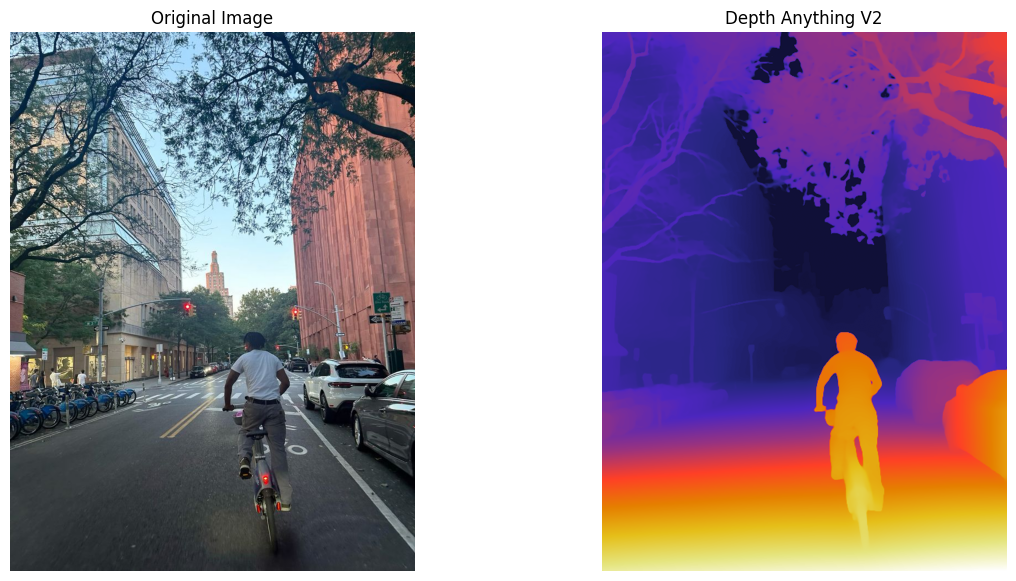

In [26]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

image = Image.open("biking in nyc _3.jpg").convert("RGB")
depth = np.load("depth_output/depth.npy")

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].imshow(image)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(depth, cmap="CMRmap")
axes[1].set_title("Depth Anything V2")
axes[1].axis("off")

plt.show()

In [30]:
wide_depth = estimate_depth("YOUR_WIDE_IMAGE.jpg", "wide_output")

print(wide_depth.shape)

Depth estimation completed.
Image size: (706, 242)
Depth size: (242, 706)
Data type: float32
Minimum: 0.7976551055908203
Maximum: 2.506110668182373
(242, 706)


In [32]:
dark_depth = estimate_depth("YOUR_DARK_IMAGE.jpg", "dark_output")

Depth estimation completed.
Image size: (735, 490)
Depth size: (490, 735)
Data type: float32
Minimum: 0.7037286162376404
Maximum: 4.035828113555908


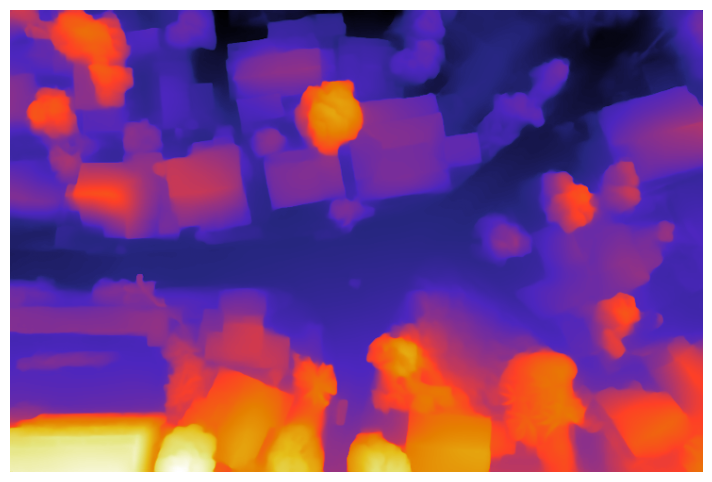

In [33]:
plt.figure(figsize=(10, 6))
plt.imshow(dark_depth, cmap="CMRmap")
plt.axis("off")
plt.show()

In [34]:
final_depth = estimate_depth(
    "biking in nyc _3.jpg",
    "final_output"
)

Depth estimation completed.
Image size: (736, 981)
Depth size: (981, 736)
Data type: float32
Minimum: -0.43340417742729187
Maximum: 7.46762752532959


In [35]:
import shutil

shutil.make_archive(
    "DepthWizard_Role1_Output",
    "zip",
    "final_output"
)

print("Created DepthWizard_Role1_Output.zip")

Created DepthWizard_Role1_Output.zip
